# Recovery Point XGBoost Training - Clean Rebuilt Notebook

This notebook is rebuilt for `recovery_points_training_data_v7(1).xlsx`.

It uses:
- uppercase Excel columns
- YAML scoring rules
- XGBoost only
- train / validation / test split
- Stratified K-Fold on training data
- prediction dataframe without target leakage


## 1. Install packages

```bash
pip install -r requirements_recovery_point.txt
```


In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import ParameterGrid, StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

from recovery_point_common import (
    TRAINING_REQUIRED_COLUMNS,
    build_feature_matrix,
    build_preprocessor,
    load_yaml,
    normalize_columns,
    score_with_yaml,
    validate_columns,
)

RANDOM_STATE = 42
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)


## 2. File paths

In [5]:
excel_path = 'recovery_points_training_data_v7.xlsx'
training_sheet = 'Recovery Points Training Data'
test_prediction_sheet = 'Test Prediction Data'
yaml_path = 'scoring_rules_v7.yaml'


## 3. Load files

In [6]:
rules = load_yaml(yaml_path)
raw_df = pd.read_excel(excel_path, sheet_name=training_sheet)
train_df = normalize_columns(raw_df)
validate_columns(train_df, TRAINING_REQUIRED_COLUMNS)

print('Shape:', train_df.shape)
print(train_df.columns.tolist())
display(train_df.head())


Shape: (1200, 14)
['ACTIVATED_PLAN_ID', 'GROUP_ID', 'COPY_TYPE', 'SOURCE_SYSTEM', 'SOURCE_TYPE', 'SCANNABLE', 'SCAN_JOB_RESULT_RAW', 'SCAN_JOB_RESULT', 'VALIDATION_SUCCESSFUL_RAW', 'VALIDATION_STATUS', 'IS_LATEST', 'IMMUTABLE', 'MALWARE_ANOMALY_DETECTED', 'LABEL']


,ACTIVATED_PLAN_ID,GROUP_ID,COPY_TYPE,SOURCE_SYSTEM,SOURCE_TYPE,SCANNABLE,SCAN_JOB_RESULT_RAW,SCAN_JOB_RESULT,VALIDATION_SUCCESSFUL_RAW,VALIDATION_STATUS,IS_LATEST,IMMUTABLE,MALWARE_ANOMALY_DETECTED,LABEL
0,69dfdb0524e15fce77bcccbc,3df29a5f-3341-43a2-b532-617a51c1f1cd,SAFEGUARDED_COPY,tsmaf5200a.storage.tucson.ibm.com,flashsystem,False,NaN,NON_SCANNABLE,NaN,UNKNOWN,True,NaN,False,GOOD
1,69df873b24e15fce77a9c8eb,3df29a5f-3341-43a2-b532-617a51c1f1cd,SAFEGUARDED_COPY,tsmaf5200a.storage.tucson.ibm.com,flashsystem,False,NaN,NON_SCANNABLE,NaN,UNKNOWN,False,NaN,False,ACCEPTABLE
2,69df32c024e15fce7796492e,3df29a5f-3341-43a2-b532-617a51c1f1cd,SAFEGUARDED_COPY,tsmaf5200a.storage.tucson.ibm.com,flashsystem,False,NaN,NON_SCANNABLE,NaN,UNKNOWN,False,NaN,False,ACCEPTABLE
3,69dede3224e15fce77832c5a,3df29a5f-3341-43a2-b532-617a51c1f1cd,SAFEGUARDED_COPY,tsmaf5200a.storage.tucson.ibm.com,flashsystem,False,NaN,NON_SCANNABLE,NaN,UNKNOWN,False,NaN,False,ACCEPTABLE
4,69de8c2e24e15fce77772b77,3df29a5f-3341-43a2-b532-617a51c1f1cd,SAFEGUARDED_COPY,tsmaf5200a.storage.tucson.ibm.com,flashsystem,True,FAILED,FAILED,NaN,UNKNOWN,False,NaN,False,ACCEPTABLE


## 4. Apply YAML scoring

In [7]:
train_scored = score_with_yaml(train_df, rules)
display(train_scored.head())


,ACTIVATED_PLAN_ID,GROUP_ID,COPY_TYPE,SOURCE_SYSTEM,SOURCE_TYPE,SCANNABLE,SCAN_JOB_RESULT_RAW,SCAN_JOB_RESULT,VALIDATION_SUCCESSFUL_RAW,VALIDATION_STATUS,IS_LATEST,IMMUTABLE,MALWARE_ANOMALY_DETECTED,LABEL,SCAN_RESULT_NORM,VALIDATION_STATUS_NORM,SCORE_MALWARE,SCORE_SCANNER,SCORE_VALIDATION,SCORE_LATEST,IMMUTABLE_FLAG,SCORE_IMMUTABLE,TOTAL_SCORE,DANGER_MALWARE,DANGER_SCANNER,DANGER_VALIDATION,DANGER_COUNT,RULE_LABEL
0,69dfdb0524e15fce77bcccbc,3df29a5f-3341-43a2-b532-617a51c1f1cd,SAFEGUARDED_COPY,tsmaf5200a.storage.tucson.ibm.com,flashsystem,False,NaN,NON_SCANNABLE,NaN,UNKNOWN,True,NaN,False,GOOD,NON_SCANNABLE,UNKNOWN,50,0,0,20,UNKNOWN,0,70,0,0,0,0,GOOD
1,69df873b24e15fce77a9c8eb,3df29a5f-3341-43a2-b532-617a51c1f1cd,SAFEGUARDED_COPY,tsmaf5200a.storage.tucson.ibm.com,flashsystem,False,NaN,NON_SCANNABLE,NaN,UNKNOWN,False,NaN,False,ACCEPTABLE,NON_SCANNABLE,UNKNOWN,50,0,0,0,UNKNOWN,0,50,0,0,0,0,ACCEPTABLE
2,69df32c024e15fce7796492e,3df29a5f-3341-43a2-b532-617a51c1f1cd,SAFEGUARDED_COPY,tsmaf5200a.storage.tucson.ibm.com,flashsystem,False,NaN,NON_SCANNABLE,NaN,UNKNOWN,False,NaN,False,ACCEPTABLE,NON_SCANNABLE,UNKNOWN,50,0,0,0,UNKNOWN,0,50,0,0,0,0,ACCEPTABLE
3,69dede3224e15fce77832c5a,3df29a5f-3341-43a2-b532-617a51c1f1cd,SAFEGUARDED_COPY,tsmaf5200a.storage.tucson.ibm.com,flashsystem,False,NaN,NON_SCANNABLE,NaN,UNKNOWN,False,NaN,False,ACCEPTABLE,NON_SCANNABLE,UNKNOWN,50,0,0,0,UNKNOWN,0,50,0,0,0,0,ACCEPTABLE
4,69de8c2e24e15fce77772b77,3df29a5f-3341-43a2-b532-617a51c1f1cd,SAFEGUARDED_COPY,tsmaf5200a.storage.tucson.ibm.com,flashsystem,True,FAILED,FAILED,NaN,UNKNOWN,False,NaN,False,ACCEPTABLE,FAILED,UNKNOWN,50,0,0,0,UNKNOWN,0,50,0,0,0,0,ACCEPTABLE


## 5. Basic data checks

In [8]:
print('Missing values:')
display(train_df.isna().sum().sort_values(ascending=False).to_frame('missing_count'))

print('Label distribution:')
display(train_scored['LABEL'].value_counts().to_frame('count'))

print('Rule label distribution:')
display(train_scored['RULE_LABEL'].value_counts().to_frame('count'))

alignment = (train_scored['LABEL'].astype(str).str.upper() == train_scored['RULE_LABEL'].astype(str).str.upper()).mean()
print('Rule label vs Excel label alignment:', round(alignment, 4))


Missing values:


,missing_count
SCAN_JOB_RESULT_RAW,635
VALIDATION_SUCCESSFUL_RAW,461
IMMUTABLE,379
ACTIVATED_PLAN_ID,0
GROUP_ID,0
COPY_TYPE,0
SOURCE_SYSTEM,0
SOURCE_TYPE,0
SCANNABLE,0
SCAN_JOB_RESULT,0


Label distribution:


,count
LABEL,
RISKY,378
AVOID,239
BEST,207
ACCEPTABLE,204
GOOD,172


Rule label distribution:


,count
RULE_LABEL,
RISKY,378
AVOID,228
BEST,212
ACCEPTABLE,204
GOOD,178


Rule label vs Excel label alignment: 0.9908


## 6. Target distribution plot

In [ ]:
label_counts = train_scored['LABEL'].value_counts().sort_index()
plt.figure(figsize=(8, 5))
plt.bar(label_counts.index, label_counts.values)
plt.title('Target Class Distribution')
plt.xlabel('LABEL')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 7. EDA by business fields

LABEL,ACCEPTABLE,AVOID,BEST,GOOD,RISKY
SCAN_RESULT_NORM,,,,,
CLEAN,0,12,80,21,34
FAILED,23,10,18,31,21
INCONCLUSIVE,0,8,38,29,18
INFECTED,0,44,0,0,15
MALICIOUS,0,69,0,0,18
NON_SCANNABLE,154,31,46,56,216
NOT_SCANNED,27,19,25,35,26
SUSPICIOUS,0,46,0,0,30


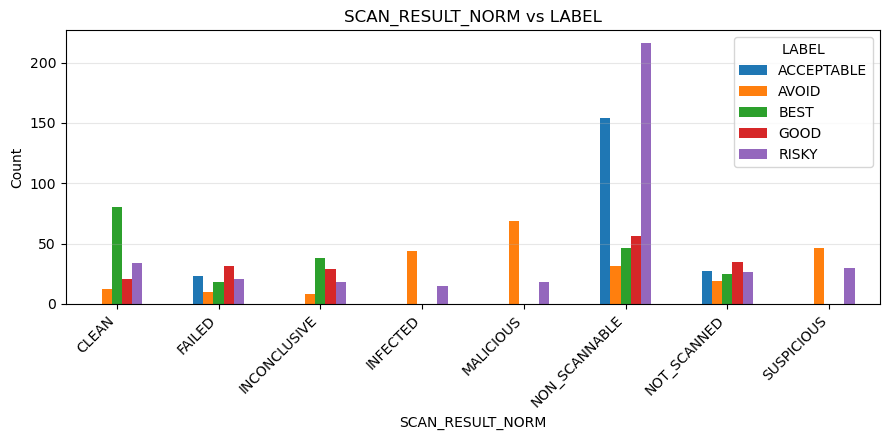

LABEL,ACCEPTABLE,AVOID,BEST,GOOD,RISKY
VALIDATION_STATUS_NORM,,,,,
INVALID,0,189,0,0,227
UNKNOWN,204,20,24,127,86
VALIDATED,0,30,183,45,65


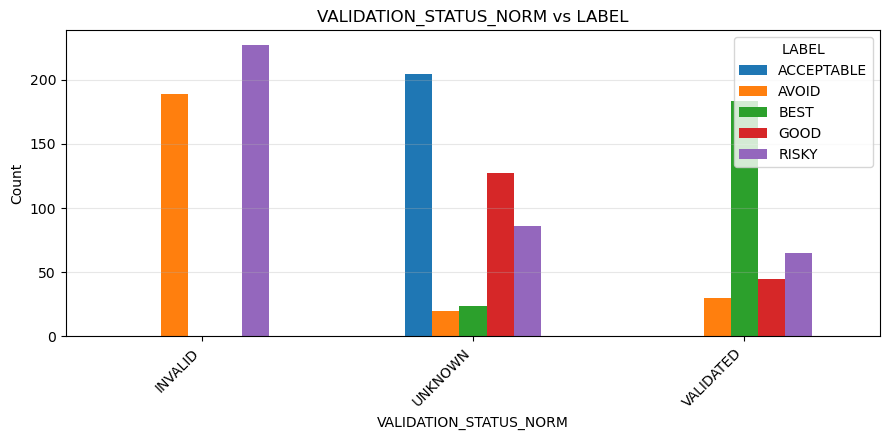

LABEL,ACCEPTABLE,AVOID,BEST,GOOD,RISKY
COPY_TYPE,,,,,
Backup,133,147,114,114,255
SAFEGUARDED_COPY,48,34,47,24,34
Snapshot,23,58,46,34,89


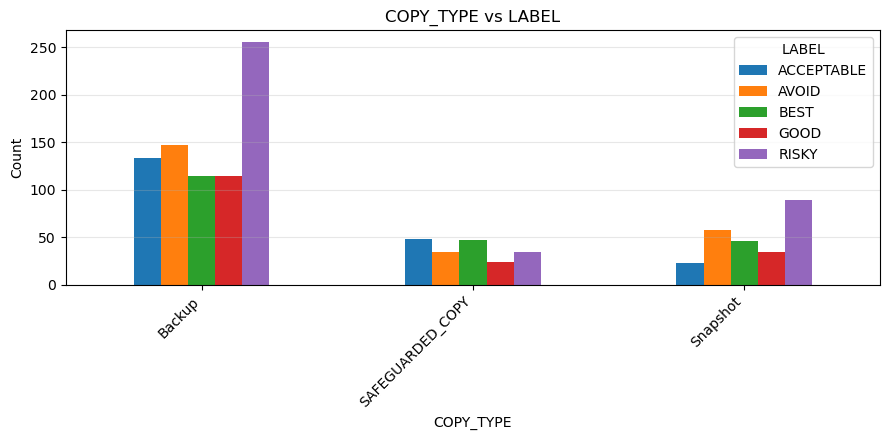

LABEL,ACCEPTABLE,AVOID,BEST,GOOD,RISKY
SOURCE_TYPE,,,,,
cdp,100,52,30,43,176
dellpowermax,5,0,0,1,0
flashsystem,64,66,78,50,61
ibm_data_protect,10,49,61,37,55
object_store,2,21,5,22,24
purestorage,0,3,0,0,31
tape,23,48,33,19,31


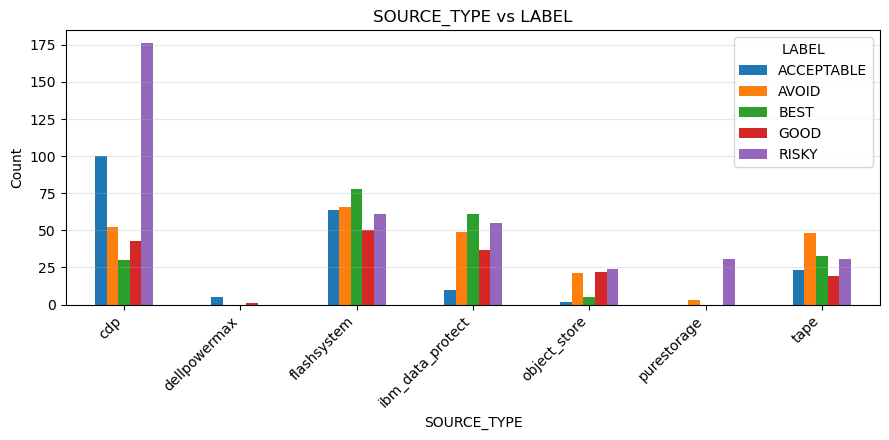

LABEL,ACCEPTABLE,AVOID,BEST,GOOD,RISKY
IMMUTABLE_FLAG,,,,,
FALSE,77,148,64,105,118
TRUE,0,54,136,53,66
UNKNOWN,127,37,7,14,194


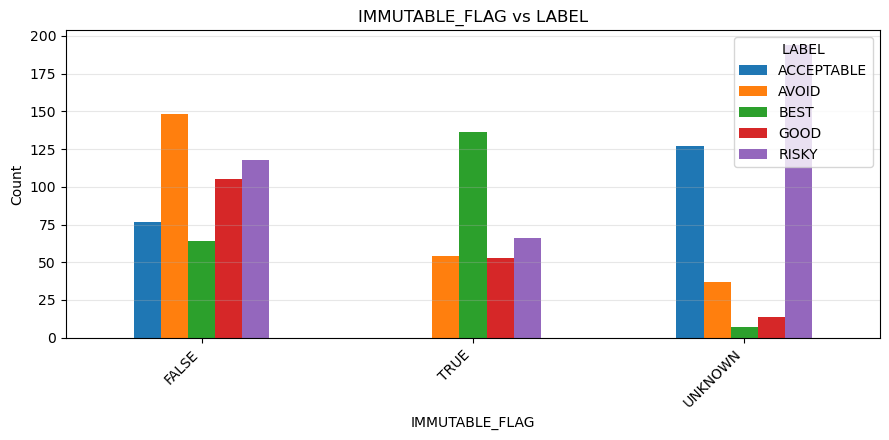

In [9]:
for col in ['SCAN_RESULT_NORM', 'VALIDATION_STATUS_NORM', 'COPY_TYPE', 'SOURCE_TYPE', 'IMMUTABLE_FLAG']:
    ctab = pd.crosstab(train_scored[col], train_scored['LABEL'])
    display(ctab)
    ctab.plot(kind='bar', figsize=(9, 4.5))
    plt.title(f'{col} vs LABEL')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


## 8. Score feature distributions

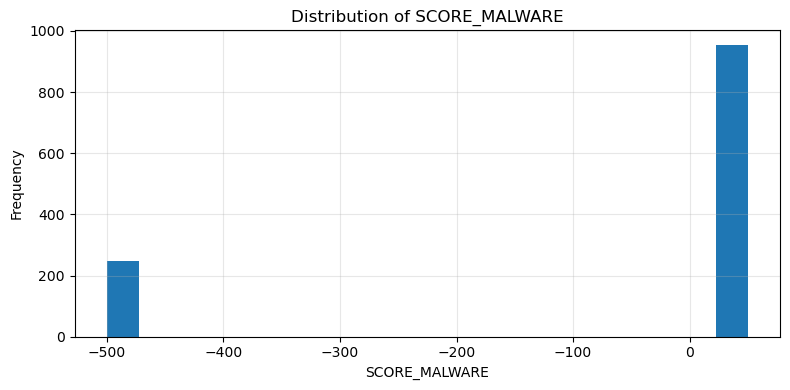

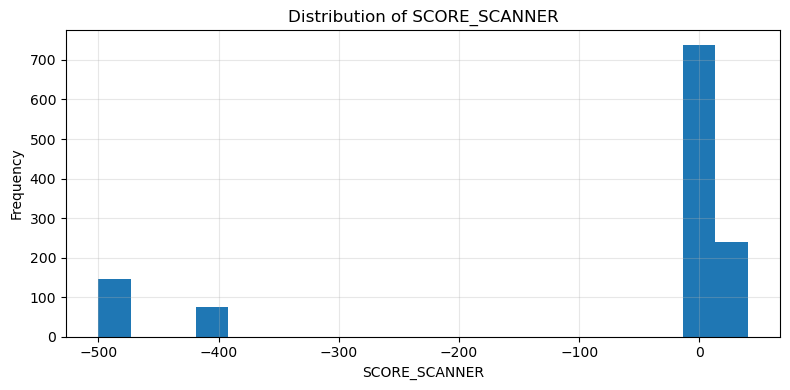

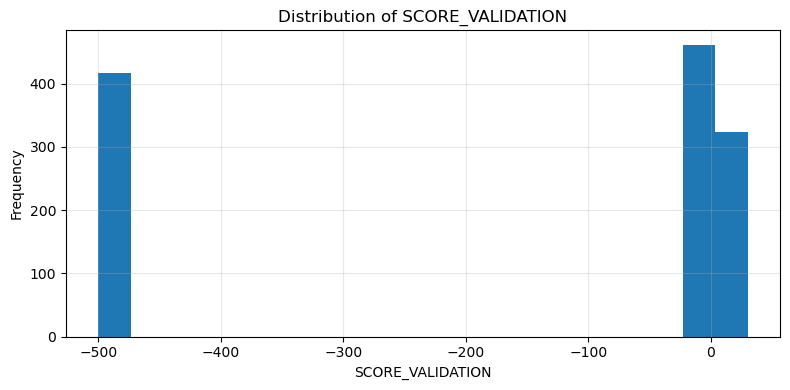

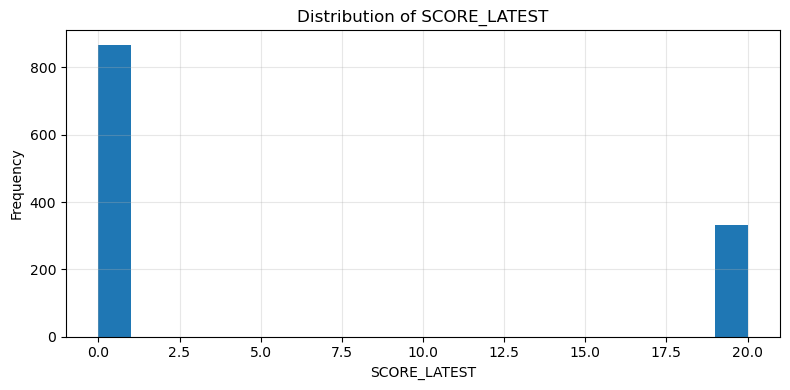

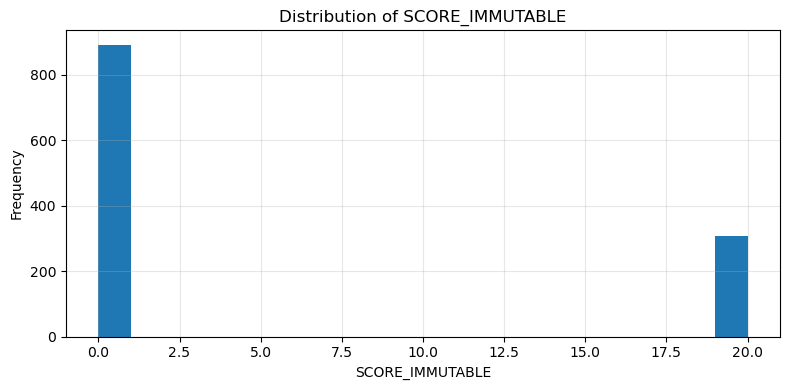

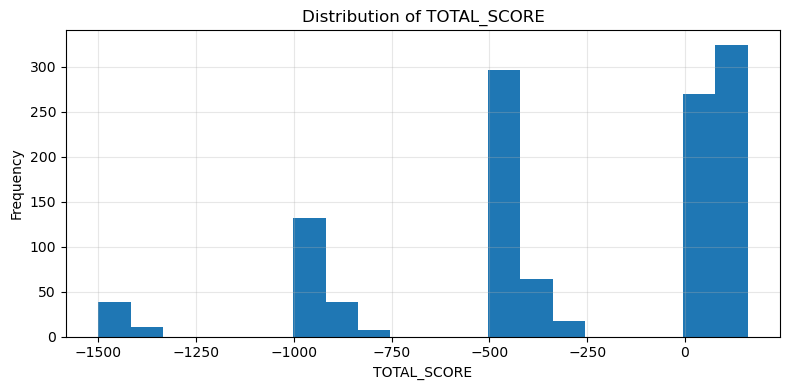

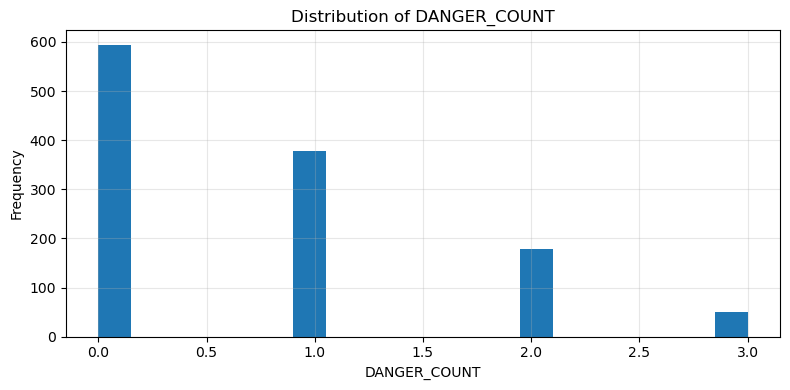

In [10]:
score_cols = ['SCORE_MALWARE','SCORE_SCANNER','SCORE_VALIDATION','SCORE_LATEST','SCORE_IMMUTABLE','TOTAL_SCORE','DANGER_COUNT']
for col in score_cols:
    plt.figure(figsize=(8, 4))
    plt.hist(train_scored[col], bins=20)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


## 9. Build features and target

In [11]:
X, categorical_cols, numeric_cols = build_feature_matrix(train_scored)
y = train_scored['LABEL'].astype(str).str.upper()

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print('X shape:', X.shape)
print('Classes:', label_encoder.classes_.tolist())
display(X.head())


X shape: (1200, 16)
Classes: ['ACCEPTABLE', 'AVOID', 'BEST', 'GOOD', 'RISKY']


,COPY_TYPE,SOURCE_SYSTEM,SOURCE_TYPE,SCANNABLE,SCAN_RESULT_NORM,VALIDATION_STATUS_NORM,IS_LATEST,IMMUTABLE_FLAG,MALWARE_ANOMALY_DETECTED,SCORE_MALWARE,SCORE_SCANNER,SCORE_VALIDATION,SCORE_LATEST,SCORE_IMMUTABLE,TOTAL_SCORE,DANGER_COUNT
0,SAFEGUARDED_COPY,tsmaf5200a.storage.tucson.ibm.com,FLASHSYSTEM,False,NON_SCANNABLE,UNKNOWN,True,UNKNOWN,False,50.0,0.0,0.0,20.0,0.0,70.0,0
1,SAFEGUARDED_COPY,tsmaf5200a.storage.tucson.ibm.com,FLASHSYSTEM,False,NON_SCANNABLE,UNKNOWN,False,UNKNOWN,False,50.0,0.0,0.0,0.0,0.0,50.0,0
2,SAFEGUARDED_COPY,tsmaf5200a.storage.tucson.ibm.com,FLASHSYSTEM,False,NON_SCANNABLE,UNKNOWN,False,UNKNOWN,False,50.0,0.0,0.0,0.0,0.0,50.0,0
3,SAFEGUARDED_COPY,tsmaf5200a.storage.tucson.ibm.com,FLASHSYSTEM,False,NON_SCANNABLE,UNKNOWN,False,UNKNOWN,False,50.0,0.0,0.0,0.0,0.0,50.0,0
4,SAFEGUARDED_COPY,tsmaf5200a.storage.tucson.ibm.com,FLASHSYSTEM,True,FAILED,UNKNOWN,False,UNKNOWN,False,50.0,0.0,0.0,0.0,0.0,50.0,0


## 10. Train / validation / test split

In [12]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y_encoded, test_size=0.15, stratify=y_encoded, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.15, stratify=y_trainval, random_state=RANDOM_STATE
)
print('Train:', X_train.shape)
print('Validation:', X_val.shape)
print('Test:', X_test.shape)


Train: (867, 16)
Validation: (153, 16)
Test: (180, 16)


## 11. XGBoost pipeline

In [13]:
preprocessor = build_preprocessor()

def build_xgb_pipeline(params):
    model = XGBClassifier(
        objective='multi:softprob',
        num_class=len(label_encoder.classes_),
        eval_metric='mlogloss',
        tree_method='hist',
        random_state=RANDOM_STATE,
        **params,
    )
    from sklearn.pipeline import Pipeline
    return Pipeline([('preprocessor', preprocessor), ('model', model)])


## 12. Stratified K-Fold model selection

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
param_grid = {
    'n_estimators': [250, 400],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.85],
    'colsample_bytree': [0.85],
    'min_child_weight': [1, 3],
    'reg_lambda': [1.0],
}

cv_rows = []
best_params = None
best_score = -1
for params in ParameterGrid(param_grid):
    macro_scores = []
    weighted_scores = []
    for tr_idx, va_idx in cv.split(X_train, y_train):
        pipe = build_xgb_pipeline(params)
        pipe.fit(X_train.iloc[tr_idx], y_train[tr_idx])
        pred = pipe.predict(X_train.iloc[va_idx])
        macro_scores.append(f1_score(y_train[va_idx], pred, average='macro'))
        weighted_scores.append(f1_score(y_train[va_idx], pred, average='weighted'))
    row = dict(params)
    row['cv_f1_macro'] = float(np.mean(macro_scores))
    row['cv_f1_weighted'] = float(np.mean(weighted_scores))
    cv_rows.append(row)
    if row['cv_f1_macro'] > best_score:
        best_score = row['cv_f1_macro']
        best_params = params

cv_results = pd.DataFrame(cv_rows).sort_values(['cv_f1_macro','cv_f1_weighted'], ascending=False).reset_index(drop=True)
display(cv_results.head(10))
print(json.dumps(best_params, indent=2))


,colsample_bytree,learning_rate,max_depth,min_child_weight,n_estimators,reg_lambda,subsample,cv_f1_macro,cv_f1_weighted
0,0.85,0.05,4,1,250,1.0,0.85,0.994601,0.995383
1,0.85,0.05,4,1,400,1.0,0.85,0.994601,0.995383
2,0.85,0.05,6,1,250,1.0,0.85,0.994601,0.995383
3,0.85,0.05,6,1,400,1.0,0.85,0.994601,0.995383
4,0.85,0.10,4,1,250,1.0,0.85,0.994601,0.995383
5,0.85,0.10,4,1,400,1.0,0.85,0.994601,0.995383
6,0.85,0.10,6,1,250,1.0,0.85,0.994601,0.995383
7,0.85,0.10,6,1,400,1.0,0.85,0.994601,0.995383
8,0.85,0.10,4,3,400,1.0,0.85,0.992110,0.993087
9,0.85,0.05,4,3,400,1.0,0.85,0.990712,0.991935


{
  "colsample_bytree": 0.85,
  "learning_rate": 0.05,
  "max_depth": 4,
  "min_child_weight": 1,
  "n_estimators": 250,
  "reg_lambda": 1.0,
  "subsample": 0.85
}


## 13. Validation evaluation

Validation accuracy: 0.9934640522875817
Validation macro F1: 0.9929477265697495
              precision    recall  f1-score   support

  ACCEPTABLE     1.0000    1.0000    1.0000        26
       AVOID     1.0000    0.9677    0.9836        31
        BEST     0.9630    1.0000    0.9811        26
        GOOD     1.0000    1.0000    1.0000        22
       RISKY     1.0000    1.0000    1.0000        48

    accuracy                         0.9935       153
   macro avg     0.9926    0.9935    0.9929       153
weighted avg     0.9937    0.9935    0.9935       153



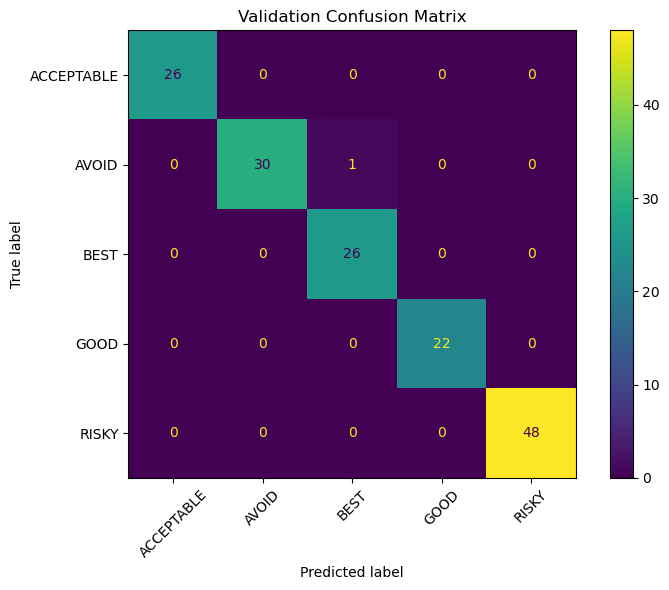

In [15]:
val_pipeline = build_xgb_pipeline(best_params)
val_pipeline.fit(X_train, y_train)
val_pred = val_pipeline.predict(X_val)

print('Validation accuracy:', accuracy_score(y_val, val_pred))
print('Validation macro F1:', f1_score(y_val, val_pred, average='macro'))
print(classification_report(y_val, val_pred, target_names=label_encoder.classes_, digits=4))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_val, val_pred, display_labels=label_encoder.classes_, ax=ax, xticks_rotation=45)
plt.title('Validation Confusion Matrix')
plt.tight_layout()
plt.show()


## 14. Final model and test evaluation

Test accuracy: 1.0
Test macro F1: 1.0
              precision    recall  f1-score   support

  ACCEPTABLE     1.0000    1.0000    1.0000        30
       AVOID     1.0000    1.0000    1.0000        36
        BEST     1.0000    1.0000    1.0000        31
        GOOD     1.0000    1.0000    1.0000        26
       RISKY     1.0000    1.0000    1.0000        57

    accuracy                         1.0000       180
   macro avg     1.0000    1.0000    1.0000       180
weighted avg     1.0000    1.0000    1.0000       180



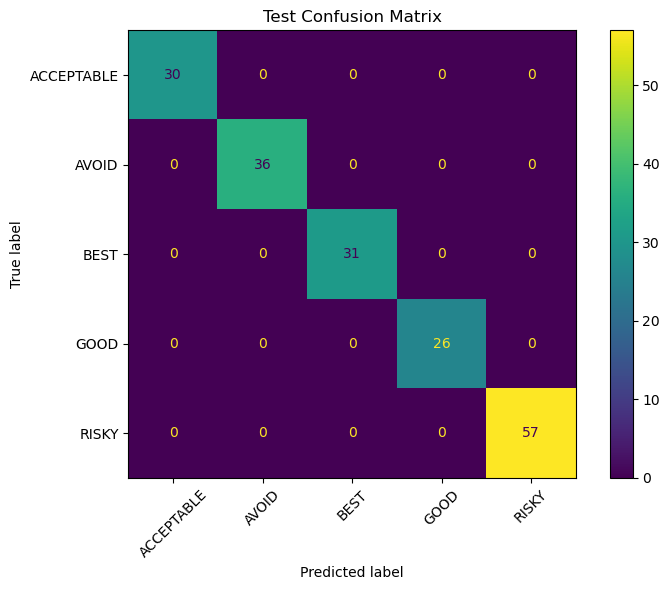

In [16]:
final_pipeline = build_xgb_pipeline(best_params)
final_pipeline.fit(X_trainval, y_trainval)
test_pred = final_pipeline.predict(X_test)

print('Test accuracy:', accuracy_score(y_test, test_pred))
print('Test macro F1:', f1_score(y_test, test_pred, average='macro'))
print(classification_report(y_test, test_pred, target_names=label_encoder.classes_, digits=4))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, test_pred, display_labels=label_encoder.classes_, ax=ax, xticks_rotation=45)
plt.title('Test Confusion Matrix')
plt.tight_layout()
plt.show()


## 15. Test prediction dataframe

In [17]:
test_output = train_scored.loc[X_test.index, [
    'ACTIVATED_PLAN_ID','GROUP_ID','COPY_TYPE','SOURCE_SYSTEM','SCAN_RESULT_NORM','VALIDATION_STATUS_NORM',
    'IS_LATEST','IMMUTABLE_FLAG','MALWARE_ANOMALY_DETECTED','RULE_LABEL','TOTAL_SCORE','DANGER_COUNT'
]].copy()
test_output['ACTUAL_LABEL'] = label_encoder.inverse_transform(y_test)
test_output['PREDICTED_LABEL'] = label_encoder.inverse_transform(test_pred)
proba = final_pipeline.predict_proba(X_test)
proba_df = pd.DataFrame(proba, columns=[f'PROBA_{c}' for c in label_encoder.classes_], index=X_test.index)
test_output = pd.concat([test_output, proba_df], axis=1)
test_output = test_output.sort_values(['GROUP_ID','PROBA_BEST','TOTAL_SCORE'], ascending=[True,False,False])
display(test_output.head(30))


,ACTIVATED_PLAN_ID,GROUP_ID,COPY_TYPE,SOURCE_SYSTEM,SCAN_RESULT_NORM,VALIDATION_STATUS_NORM,IS_LATEST,IMMUTABLE_FLAG,MALWARE_ANOMALY_DETECTED,RULE_LABEL,TOTAL_SCORE,DANGER_COUNT,ACTUAL_LABEL,PREDICTED_LABEL,PROBA_ACCEPTABLE,PROBA_AVOID,PROBA_BEST,PROBA_GOOD,PROBA_RISKY
299,69714cd962dcdd3fcff96064,209387af-b1ce-4195-8d8c-31f364f4b6a0,Snapshot,9.11.42.91,NON_SCANNABLE,INVALID,False,UNKNOWN,False,RISKY,-450,1,RISKY,RISKY,0.000351,0.001351,0.000123,0.000150,0.998025
0,69dfdb0524e15fce77bcccbc,3df29a5f-3341-43a2-b532-617a51c1f1cd,SAFEGUARDED_COPY,tsmaf5200a.storage.tucson.ibm.com,NON_SCANNABLE,UNKNOWN,True,UNKNOWN,False,GOOD,70,0,GOOD,GOOD,0.006436,0.001646,0.001842,0.987961,0.002114
2,69df32c024e15fce7796492e,3df29a5f-3341-43a2-b532-617a51c1f1cd,SAFEGUARDED_COPY,tsmaf5200a.storage.tucson.ibm.com,NON_SCANNABLE,UNKNOWN,False,UNKNOWN,False,ACCEPTABLE,50,0,ACCEPTABLE,ACCEPTABLE,0.997606,0.000409,0.000432,0.000984,0.000569
188,69812711697d5378eda5e046,4535b2d7-62d9-481e-b8ad-9668476061dd,Backup,defender-ready.storage.tucson.ibm.com,NON_SCANNABLE,INVALID,False,UNKNOWN,False,RISKY,-450,1,RISKY,RISKY,0.000352,0.000815,0.000131,0.000146,0.998557
259,6981270d697d5378eda5cf13,4535b2d7-62d9-481e-b8ad-9668476061dd,Backup,defender-ready.storage.tucson.ibm.com,NON_SCANNABLE,INVALID,False,UNKNOWN,False,RISKY,-450,1,RISKY,RISKY,0.000352,0.000815,0.000131,0.000146,0.998557
213,6981270f697d5378eda5da3e,4535b2d7-62d9-481e-b8ad-9668476061dd,Backup,defender-ready.storage.tucson.ibm.com,NON_SCANNABLE,INVALID,False,UNKNOWN,False,RISKY,-450,1,RISKY,RISKY,0.000352,0.000815,0.000131,0.000146,0.998557
201,69812710697d5378eda5dd1b,4535b2d7-62d9-481e-b8ad-9668476061dd,Backup,defender-ready.storage.tucson.ibm.com,NON_SCANNABLE,INVALID,False,UNKNOWN,False,RISKY,-450,1,RISKY,RISKY,0.000352,0.000815,0.000131,0.000146,0.998557
187,69812711697d5378eda5e08f,4535b2d7-62d9-481e-b8ad-9668476061dd,Backup,defender-ready.storage.tucson.ibm.com,NON_SCANNABLE,INVALID,False,UNKNOWN,False,RISKY,-450,1,RISKY,RISKY,0.000352,0.000815,0.000131,0.000146,0.998557
247,6981270e697d5378eda5d286,4535b2d7-62d9-481e-b8ad-9668476061dd,Backup,defender-ready.storage.tucson.ibm.com,NON_SCANNABLE,INVALID,False,UNKNOWN,False,RISKY,-450,1,RISKY,RISKY,0.000352,0.000815,0.000131,0.000146,0.998557
196,69812710697d5378eda5de34,4535b2d7-62d9-481e-b8ad-9668476061dd,Backup,defender-ready.storage.tucson.ibm.com,NON_SCANNABLE,INVALID,False,UNKNOWN,False,RISKY,-450,1,RISKY,RISKY,0.000352,0.000815,0.000131,0.000146,0.998557


## 16. Save model artifacts

In [ ]:
model_bundle = {
    'pipeline': final_pipeline,
    'label_encoder': label_encoder,
    'rules': rules,
    'best_params': best_params,
    'feature_columns': list(X.columns),
}
joblib.dump(model_bundle, 'recovery_point_xgb_model.joblib')
with pd.ExcelWriter('recovery_point_test_predictions.xlsx', engine='openpyxl') as writer:
    test_output.to_excel(writer, sheet_name='test_predictions', index=False)
    cv_results.to_excel(writer, sheet_name='cv_results', index=False)
print('Saved recovery_point_xgb_model.joblib')
print('Saved recovery_point_test_predictions.xlsx')


## 17. Predict best recovery point from separate test sheet

In [ ]:
test_raw = pd.read_excel(excel_path, sheet_name=test_prediction_sheet)
test_df = normalize_columns(test_raw)
test_scored = score_with_yaml(test_df, rules)
X_pred, _, _ = build_feature_matrix(test_scored)
pred_enc = final_pipeline.predict(X_pred)
pred_labels = label_encoder.inverse_transform(pred_enc)
pred_proba = final_pipeline.predict_proba(X_pred)
pred_proba_df = pd.DataFrame(pred_proba, columns=[f'PROBA_{c}' for c in label_encoder.classes_], index=X_pred.index)

pred_output = test_scored[['GROUP_ID','ACTIVATED_PLAN_ID','COPY_TYPE','SOURCE_SYSTEM','SCAN_RESULT_NORM','VALIDATION_STATUS_NORM','IS_LATEST','IMMUTABLE_FLAG','MALWARE_ANOMALY_DETECTED','TOTAL_SCORE','DANGER_COUNT','RULE_LABEL']].copy()
pred_output['PREDICTED_LABEL'] = pred_labels
pred_output = pd.concat([pred_output, pred_proba_df], axis=1)
best_per_group = pred_output.sort_values(['GROUP_ID','PROBA_BEST','TOTAL_SCORE','DANGER_COUNT'], ascending=[True,False,False,True]).groupby('GROUP_ID', as_index=False).first()
display(pred_output.head(20))
display(best_per_group.head(20))
